In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import isautilities as isau
import xarray as xr
import itertools
import scipy as sp
import warnings

import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results' / 'Figures' / 'ISAHpcPfc' / 'XCorr'
froot_poster = pathlib.Path().cwd().parent.parent.parent / 'Results' / 'PosterFigures'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def plotCMap(x,ax=None,reg=None,**kwargs):
    if ax is not None and reg is not None:
        reg = str(reg)
        ax.set(xlabel=f'{reg.split('-')[1].upper()} lag (s)',ylabel=f'{reg.split('-')[0].upper()} lag (s)')
    return fma.plotting.plotColorMap(x,x=x.lag,y=x.target,ax=ax,**kwargs)

def _laggedSpikeCrossCorr(session,regs=None,event='deltaWaves',bin=0.1,n_bins=5,step=5,target=0,shift=-1,pairs=None):
    # compute lagged cross-region pairwise unit correlation around event times as (shuffle, region, lag) XArray
    # interpretation: in 'reg1-reg2', reg1 target (controlled by 'target'), reg2 source (all are always computed)
    # time resolution will be 'bin' / 'step'
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = fma.regions.regions(session,states='sws',events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)
    if event in ['ripples','deltaWaves','spindles','down']:
        event_t, is_isa = isau.loadHpcPfcEvents(session,names=event,regions=R,isa=R.eventIntervals('slownr'),sleep=R.eventIntervals('sws'))
        event_t = event_t[event]
        is_isa = is_isa[event]
    else:
        event_t = isau.ISTransitions(isa=R.eventIntervals('slownr'),on=R.eventIntervals('slowavalnr'))[int(event=='on_off')] # CHECK
    if len(event_t) == 0:
        return None

    # make region pairs
    if pairs is None:
        reg_pair_idx = [list(p) for p in itertools.combinations(range(len(regs)),2)] # make pairs preserving order
        reg_pair_idx = reg_pair_idx + [p[::-1] for p in reg_pair_idx] # add reverse
    else:
        reg_pair_idx = pairs
    reg_pairs = [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx]
    is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids
    unit_range = {regs[i]: R.units(regs[i])[[0,-1]] if r else None for i, r in enumerate(is_reg)}

    # 1. count spikes in overlapping windows around event times
    limits = (-n_bins*bin/2, n_bins*bin/2)
    n_times = (n_bins-1) * step + 1
    peths = {}
    for j, r in enumerate(regs[is_reg]):
        s = R.spikes(r)
        peths[r], times, _ = fma.analysis.PETH(s[:,0],event_t,limits=limits,n_bins=n_bins,step=step,groups=s[:,1],g_range=unit_range[r],fast=True) # (event, lag, unit)
        if n_times != len(times):
            print('!')

    # define target times, if target is None: special case, results are one the transposed of the other
    skip = target is None
    target = np.arange(n_times) if skip else n_times//2 + np.array(target,ndmin=1) # center + offset given by 'target' input

    n_pairs = len(reg_pairs)
    spearman = np.full((2,2,n_pairs,n_times,len(target)),np.nan)
    # 0: ISA, 1: nISA
    for isa in range(2):
        valid = is_isa == isa

        # region pairs
        for i, rp in enumerate(reg_pair_idx):
            if i < n_pairs // 2 or not skip:
                if is_reg[rp[0]] and is_reg[rp[1]]:
                    ref_peth = peths[regs[rp[0]]][valid]

                    # 0: observed, 1: surrogate (roll across events)
                    for k in [0,1]:
                        lagged_peth = np.roll(peths[regs[rp[1]]][valid], shift=shift, axis=0) if k else peths[regs[rp[1]]][valid]
                        n_keep_units = lagged_peth.shape[2] # used to recover the cross-correlation block in spearmanr output

                        # source * target lags
                        for sour in range(n_times):
                            for tar, t_target in enumerate(target):
                                with np.errstate(invalid='ignore'): # suppress 0 / 0 warning
                                    with warnings.catch_warnings():
                                        warnings.filterwarnings('ignore', category=sp.stats.ConstantInputWarning)
                                        spr = sp.stats.spearmanr(lagged_peth[:,sour,:], ref_peth[:,t_target,:])[0]
                                spearman[isa,k,i,sour,tar] = np.nanmean(np.abs(spr[:n_keep_units,n_keep_units:]))
    if skip:
        spearman[:,:,n_pairs//2:,:,:] = spearman[:,:,:n_pairs//2,:,:].transpose(0,1,2,4,3)

    spearman = xr.DataArray(spearman,dims=('isa','shuffle','reg','lag','target'),coords={'isa': [True,False], 'shuffle': [False,True], 'reg': reg_pairs, 'lag': times, 'target': times[target],
                                                                                         'event': event, 'rat': int(R.rat)})
    return spearman

In [9]:
# test one session
# NOTE: bin 0.05 for curves, 0.1 ok for color maps
session = fma.data.readBatchFile(batch_file)[0][24]
print(f'session: {session}')
xdata = _laggedSpikeCrossCorr(session,event='ripples',bin=0.1,n_bins=5,step=1,target=None,shift=5)

session: /mnt/hubel-data-140/karadoc/Rat004_20240313/Rat004_20240313.xml


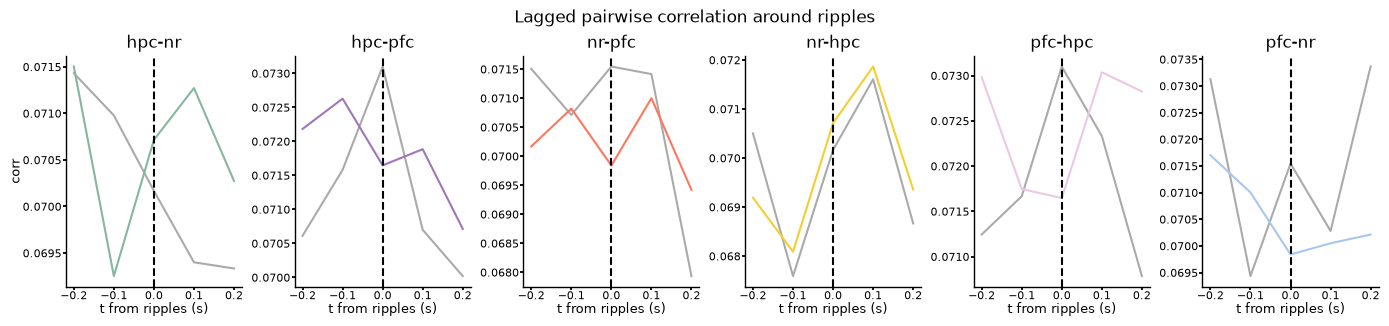

In [13]:
# interpretation: reg1 pop vector at transition correlated with reg2's delayed
fig, axs = fma.plotting.makeFigure(f'Lagged pairwise correlation around {xdata.event.values}',n=(1,6),size=(35,8))
for i, r in enumerate(xdata.reg.values):
    reg_data = xdata.sel(reg=r,target=0,isa=True)
    fma.plotting.semPlot(xdata.lag,reg_data.sel(shuffle=True),zscore=False,color=isau.paperColors('shuffle'),label=str(r.item().upper()),ax=axs[i])
    axs[i].plot(xdata.lag,reg_data.sel(shuffle=False),color=isau.paperColors(i),label=str(r.item().upper()))
    axs[i].set_xlabel(f't from {xdata.event.values} (s)'), axs[i].set_title(r)
    axs[i].axvline(0,ls='--',color='k')
axs[0].set_ylabel('corr');

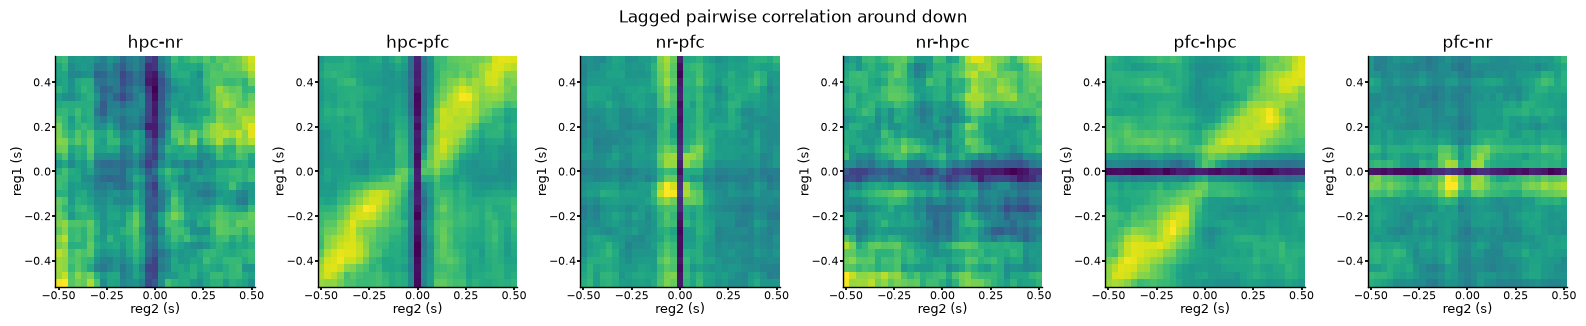

In [7]:
# interpretation: reg1 target, reg2 source
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation around {xdata.event.values}',n=(1,6),size=(40,8))
for i, r in enumerate(xdata.reg.values):
    reg_data = xdata.sel(reg=r)
    fma.plotting.plotColorMap(reg_data.sel(shuffle=False).T,x=reg_data.lag,y=reg_data.target,ax=ax[i])
    ax[i].set(title=r,xlabel='reg2 (s)',ylabel='reg1 (s)')

In [6]:
# test one session
session = fma.data.readBatchFile(batch_file)[0][30]
print(f'session: {session}')
xdata = _laggedSpikeCrossCorr(session,event='off_on',bin=0.1,n_bins=31,step=1,target=None,shift=5)

session: /mnt/hubel-data-140/karadoc/Rat004_20240319/Rat004_20240319.xml


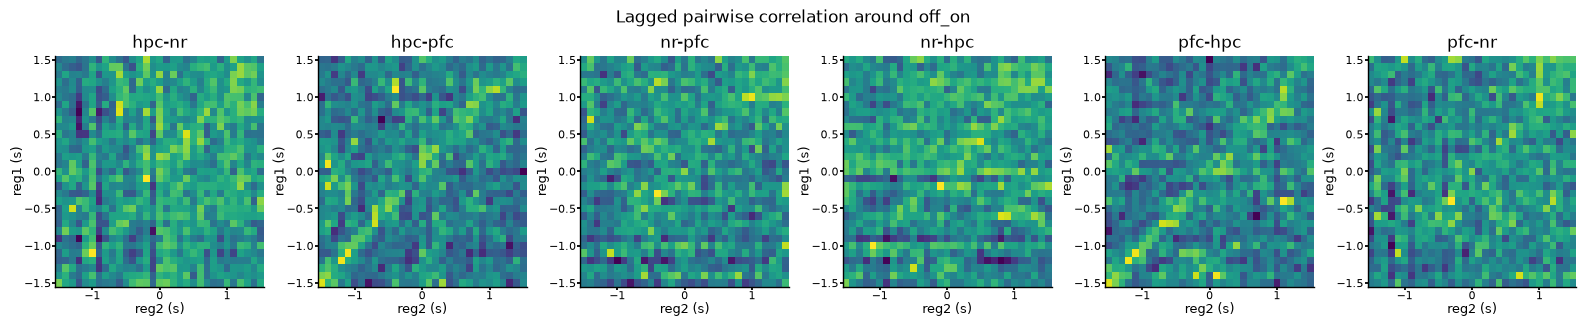

In [7]:
# see OFF-ON
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation around {xdata.event.values}',n=(1,6),size=(40,8))
for i, r in enumerate(xdata.reg.values):
    reg_data = xdata.sel(reg=r)
    fma.plotting.plotColorMap(reg_data.sel(shuffle=False).T,x=reg_data.lag,y=reg_data.target,ax=ax[i])
    ax[i].set(title=r,xlabel='reg2 (s)',ylabel='reg1 (s)')

batch for delta waves (tried wider limits, no difference)

In [3]:
regs = ['hpc','nr','pfc']
corr_delta = fma.data.runBatch(batch_file,_laggedSpikeCrossCorr,kwargs={'regs': regs, 'event': 'down', 'target': None, 'shift': -5},parallel=True)
corr_delta_cat = xr.concat([d for d in corr_delta if d is not None],dim='rat',join='outer')
corr_delta_avg = corr_delta_cat.groupby('rat').mean(dim='rat',skipna=True)


Starting Batch, 2026-09-11 15:46:47.041914 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230819/Rat002_20230819.xml (38)
'float' object is not subscriptable
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.xml (41)
/mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.sws not found.
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230823/Rat002_20230823.xml

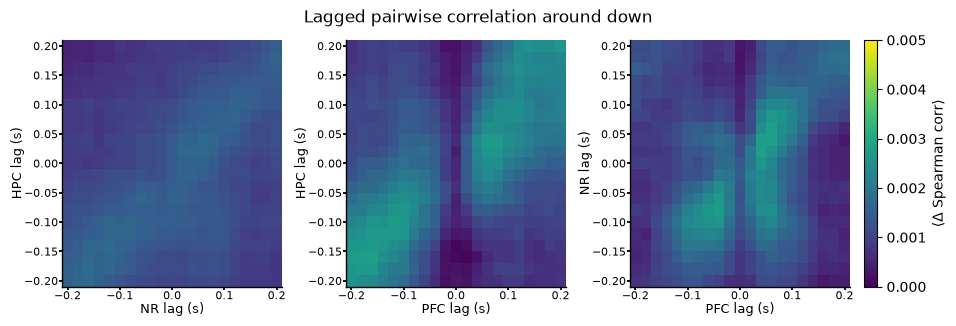

In [121]:
# interpretation: reg1 target, reg2 source
# DRAW 3D SURPHACES + PLANE THAT SLICES + one plot with 3 curves showing temporality of 3 peaks
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation around {corr_delta_cat.event.values}',n=(1,3),size=(24,8))
vmin = 0. # 0.026 # for absolute values (not difference)
vmax = 0.005 # 0.032 # for absolute values (not difference)
label = [None,None,r'$\langle$Δ Spearman corr$\rangle$']
for i, r in enumerate(corr_delta_cat.reg.values[:3]):
    reg_data = corr_delta_cat.sel(reg=r,isa=True)
    reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)

    # plot result
    plotCMap(reg_data.mean(dim='rat',skipna=True).T,vmin=vmin,vmax=vmax,bar=label[i],ax=ax[i],reg=r)

    # significance
    w = sp.stats.wilcoxon(reg_data,axis=0,nan_policy='omit',alternative='greater').pvalue
    _, h = fma.analysis.holmBonferroni(w,return_reject=True)

PFC lag: 0.06 s


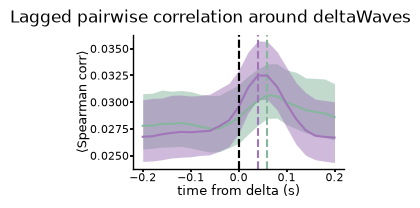

In [26]:
# plot slice of PFC at 50 ms after delta
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation around {corr_delta_cat.event.values}',size=(7,5))
for i, r in enumerate(corr_delta_cat.reg.values[1:3]):
    reg_data = corr_delta_cat.sel(reg=r).sel(target=0.05,method='nearest')
    reg_data = reg_data.sel(shuffle=False)# - reg_data.sel(shuffle=True)

    # plot result
    fma.plotting.semPlot(reg_data.lag,reg_data,ax=ax[0],color=isau.paperColors(r.split('-')[0]))

    # significance
    peak_time = np.argmax(reg_data.mean('rat').data)
    ax[0].axvline(reg_data.lag[peak_time],ls='--',color=isau.paperColors(r.split('-')[0])),
    ax[0].axvline(0,ls='--',color='k')
print(f'PFC lag: {reg_data.target.values} s')
ax[0].set(xlabel='time from delta (s)',ylabel=r'$\langle$Spearman corr$\rangle$');

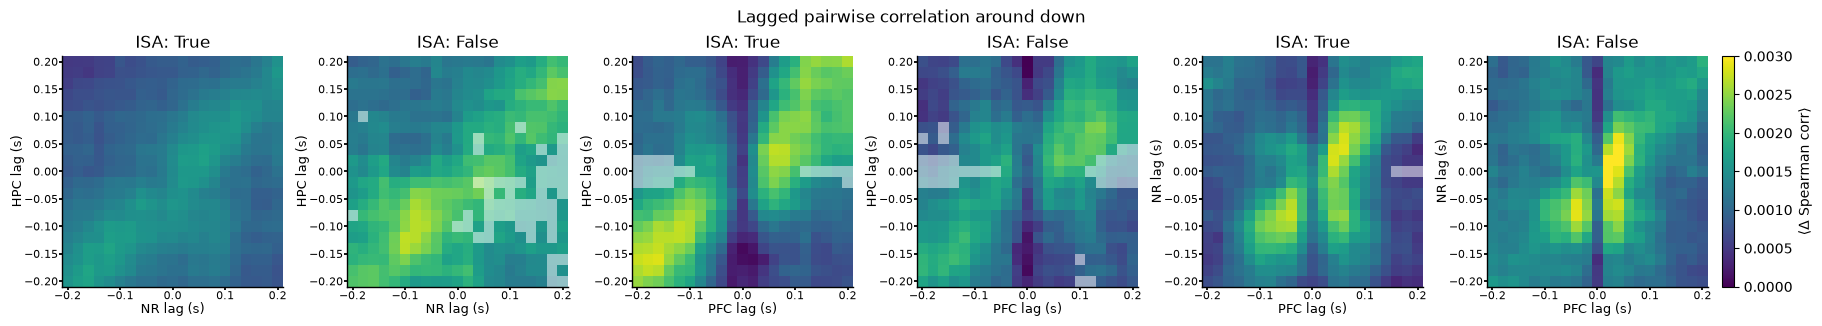

In [17]:
# divide ISA / nISA
# interpretation: reg1 target, reg2 source
# SHOW THAT LOWER TRIANGULAR PARTS ARE OF OPPOSITE MEANING! in hpc-nr and nr-pfc
# DRAW 3D SURPHACES + PLANE THAT SLICES + one plot with 3 curves showing temporality of 3 peaks
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation around {corr_delta_cat.event.values}',n=(1,6),size=(46,8))
vmin = 0.
vmax = 0.003
label = [None,None,None,None,None,r'$\langle$Δ Spearman corr$\rangle$']
for i, r in enumerate(corr_delta_cat.reg.values[:3]):
    for a, isa in enumerate([True,False]):
        reg_data = corr_delta_cat.sel(reg=r,isa=isa)
        reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)
        # significance
        w = sp.stats.wilcoxon(reg_data,axis=0,nan_policy='omit',alternative='greater').pvalue
        _, h = fma.analysis.holmBonferroni(w,return_reject=True)
        # plot result
        out = plotCMap(reg_data.mean(dim='rat',skipna=True).T,vmin=vmin,vmax=vmax,smooth=.2,alpha=np.where(h,1.0,0.5),bar=label[2*i+a],ax=ax[2*i+a],reg=r)
        label[2*i+a] is not None and out[1].ax.ticklabel_format(axis='y', style='sci', scilimits=(-2,-2))
        ax[2*i+a].set(title=f'ISA: {isa}')
do_save and fma.plotting.saveFigure(fig,froot / 'deltaXCorr2',('png','svg'))

hpc ISA True 0.06 s, hpc ISA False 0.12 s, nr ISA True 0.06 s, nr ISA False 0.04 s, 

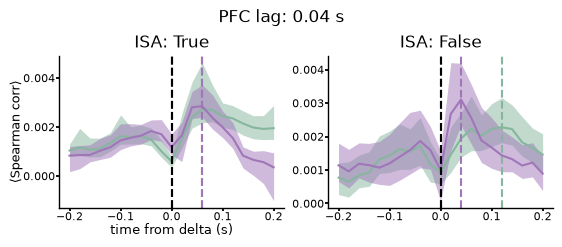

In [145]:
# plot slice of PFC at 50 ms after delta
fig, ax = fma.plotting.makeFigure(n=(1,2),size=(14,6))
for i, r in enumerate(corr_delta_cat.reg.values[1:3]):
    for a, isa in enumerate([True,False]):
        reg_data = corr_delta_cat.sel(reg=r,isa=isa).sel(target=0.03,method='nearest')
        reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)

        # plot result
        fma.plotting.semPlot(reg_data.lag,reg_data,ax=ax[a],color=isau.paperColors(r.split('-')[0]))

        # peak time
        peak_time = np.argmax(reg_data.mean('rat').data)
        ax[a].axvline(reg_data.lag[peak_time],ls='--',color=isau.paperColors(r.split('-')[0]))
        print(f'{r.item().split('-')[0]} ISA {isa} {reg_data.lag[peak_time].values:.2f} s, ',end='')
        ax[a].axvline(0,ls='--',color='k')
        ax[a].set(title=f'ISA: {isa}')
fig.suptitle(f'PFC lag: {reg_data.target.values:.2f} s')
ax[0].set(xlabel='time from delta (s)',ylabel=r'$\langle$Spearman corr$\rangle$')
do_save and fma.plotting.saveFigure(fig,froot / 'deltaXCorr',('png','svg'))

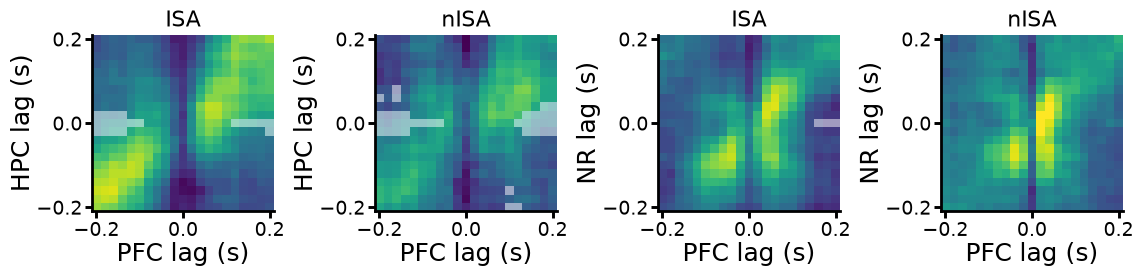

In [26]:
# poster figure
fig, ax = fma.plotting.makeFigure(n=(1,4),size=(11.5,2.7),format='poster')
vmin = 0.
vmax = 0.003
label = [None,None,None,None,None,r'$\langle$Δ Spearman corr$\rangle$']
for i, r in enumerate(corr_delta_cat.reg.values[1:3]):
    for a, isa in enumerate([True,False]):
        reg_data = corr_delta_cat.sel(reg=r,isa=isa)
        reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)
        # significance
        w = sp.stats.wilcoxon(reg_data,axis=0,nan_policy='omit',alternative='greater').pvalue
        _, h = fma.analysis.holmBonferroni(w,return_reject=True)
        # plot result
        out = plotCMap(reg_data.mean(dim='rat',skipna=True).T,vmin=vmin,vmax=vmax,smooth=.2,alpha=np.where(h,1.0,0.5),bar=label[2*i+a],ax=ax[2*i+a],reg=r)
        label[2*i+a] is not None and out[1].ax.ticklabel_format(axis='y', style='sci', scilimits=(-2,-2))
        ax[2*i+a].set_title('ISA' if isa else 'nISA',fontsize=16)
do_save and fma.plotting.saveFigure(fig,froot_poster / 'deltaXCorr2',('png','svg'))

hpc ISA True 0.06 s, hpc ISA False 0.12 s, nr ISA True 0.06 s, nr ISA False 0.04 s, 

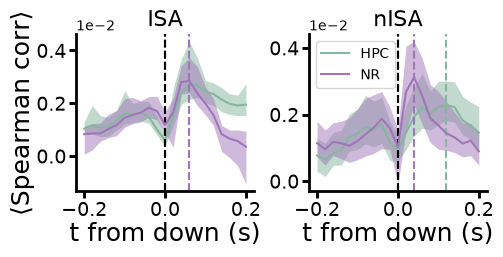

In [36]:
# poster figure
fig, ax = fma.plotting.makeFigure(n=(1,2),size=(5,2.5),format='poster')
for i, r in enumerate(corr_delta_cat.reg.values[1:3]):
    for a, isa in enumerate([True,False]):
        reg_data = corr_delta_cat.sel(reg=r,isa=isa).sel(target=0.03,method='nearest')
        reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)

        # plot result
        ax[a].axvline(0,ls='--',color='k')
        fma.plotting.semPlot(reg_data.lag,reg_data,ax=ax[a],color=isau.paperColors(r.split('-')[0]),label=r.split('-')[0].upper())

        # peak time
        peak_time = np.argmax(reg_data.mean('rat').data)
        ax[a].axvline(reg_data.lag[peak_time],ls='--',color=isau.paperColors(r.split('-')[0]))
        print(f'{r.item().split('-')[0]} ISA {isa} {reg_data.lag[peak_time].values:.2f} s, ',end='')

        ax[a].set(xlabel='t from down (s)')
        ax[a].ticklabel_format(axis='y', style='sci', scilimits=(-2,-2))
        ax[a].set_title('ISA' if isa else 'nISA',fontsize=16)
ax[0].set(ylabel=r'$\langle$Spearman corr$\rangle$'); ax[1].legend()
do_save and fma.plotting.saveFigure(fig,froot_poster / 'deltaXCorr',('png','svg'))

batch for ripples

In [37]:
corr_rip = fma.data.runBatch(batch_file,_laggedSpikeCrossCorr,kwargs={'regs': regs, 'event': 'ripples', 'target': None, 'shift': -5},parallel=True)
corr_rip_cat = xr.concat([d for d in corr_rip if d is not None],dim='rat',join='outer')


Starting Batch, 2026-09-11 17:13:41.766187 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.xml (41)
/mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.sws not found.
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230823/Rat002_20230823.xml (42)
/mnt/hubel-data-129/blinky/Rat002_20230823/Rat002_20230823.sws not found.
Traceback:
Error in session /mnt/hubel-data-149/Rat012/Rat012

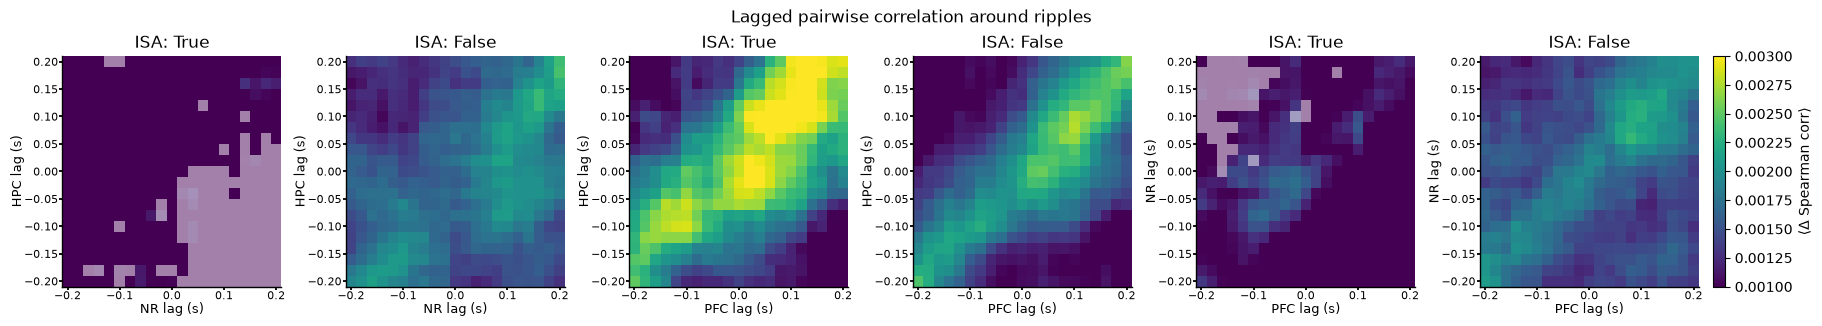

In [133]:
# divide ISA / nISA
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation around {corr_rip_cat.event.values}',n=(1,6),size=(46,8))
vmin = 0.0010
vmax = 0.003
label = [None,None,None,None,None,r'$\langle$Δ Spearman corr$\rangle$']
for i, r in enumerate(corr_rip_cat.reg.values[:3]):
    for a, isa in enumerate([True,False]):
        reg_data = corr_rip_cat.sel(reg=r,isa=isa)
        reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)
        # significance
        w = sp.stats.wilcoxon(reg_data,axis=0,nan_policy='omit',alternative='greater').pvalue
        _, h = fma.analysis.holmBonferroni(w,return_reject=True)
        # plot result
        plotCMap(reg_data.mean(dim='rat',skipna=True).T,vmin=vmin,vmax=vmax,smooth=.2,alpha=np.where(h,1.0,0.5),bar=label[2*i+a],ax=ax[2*i+a],reg=r)
        ax[2*i+a].set(title=f'ISA: {isa}')
do_save and fma.plotting.saveFigure(fig,froot / 'rippleXCorr2',('png','svg'))

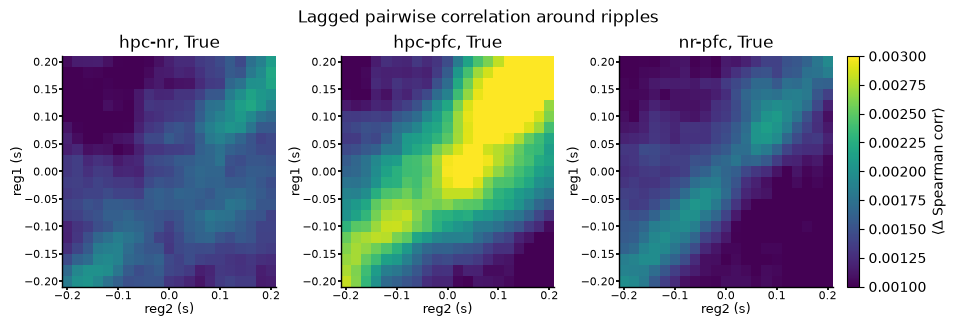

In [38]:
# interpretation: reg1 target, reg2 source
# SHOW THAT LOWER TRIANGULAR PARTS ARE OF OPPOSITE MEANING! in hpc-nr and nr-pfc
# DRAW 3D SURPHACES + PLANE THAT SLICES + one plot with 3 curves showing temporality of 3 peaks
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation around {corr_rip_cat.event.values}',n=(1,3),size=(24,8))
vmin = 0.0010
vmax = 0.003
label = [None,None,r'$\langle$Δ Spearman corr$\rangle$']
for i, r in enumerate(corr_rip_cat.reg.values[:3]):
    reg_data = corr_rip_cat.sel(reg=r)
    reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)

    # plot result
    fma.plotting.plotColorMap(reg_data.mean(dim='rat',skipna=True).T,x=reg_data.lag,y=reg_data.target,vmin=vmin,vmax=vmax,bar=label[i],ax=ax[i])

    # significance
    w = sp.stats.wilcoxon(reg_data,axis=0,nan_policy='omit',alternative='greater').pvalue
    _, h = fma.analysis.holmBonferroni(w,return_reject=True)
    ax[i].set(title=f'{r}, {np.all(h).item()}',xlabel='reg2 (s)',ylabel='reg1 (s)')

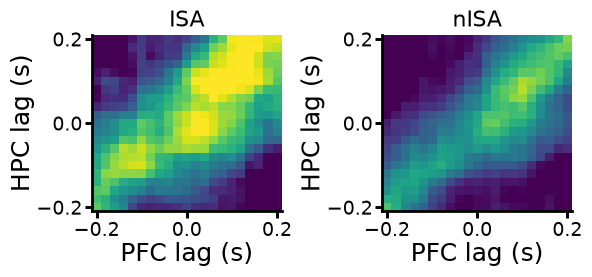

In [39]:
# poster figure
fig, ax = fma.plotting.makeFigure(n=(1,2),size=(5.9,2.7),format='poster')
vmin = 0.0010
vmax = 0.003
label = [None,None,None,None,None,r'$\langle$Δ Spearman corr$\rangle$']
for i, r in enumerate(corr_rip_cat.reg.values[1:2]):
    for a, isa in enumerate([True,False]):
        reg_data = corr_rip_cat.sel(reg=r,isa=isa)
        reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)
        # significance
        w = sp.stats.wilcoxon(reg_data,axis=0,nan_policy='omit',alternative='greater').pvalue
        _, h = fma.analysis.holmBonferroni(w,return_reject=True)
        # plot result
        out = plotCMap(reg_data.mean(dim='rat',skipna=True).T,vmin=vmin,vmax=vmax,smooth=.2,alpha=np.where(h,1.0,0.5),bar=label[2*i+a],ax=ax[2*i+a],reg=r)
        label[2*i+a] is not None and out[1].ax.ticklabel_format(axis='y', style='sci', scilimits=(-2,-2))
        ax[2*i+a].set_title('ISA' if isa else 'nISA',fontsize=16)
do_save and fma.plotting.saveFigure(fig,froot_poster / 'rippleXCorr2',('png','svg'))

TRY spindles

In [125]:
regs = ['hpc','nr','pfc']
corr_spin = fma.data.runBatch(batch_file,_laggedSpikeCrossCorr,kwargs={'regs': regs, 'event': 'spindles', 'n_bins': 40, 'step': 1, 'target': None, 'shift': -5},parallel=True)
corr_spin_cat = xr.concat([d for d in corr_spin if d is not None],dim='rat',join='outer')


Starting Batch, 2026-09-01 14:47:12.322162 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.xml (41)
/mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.sws not found.
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230823/Rat002_20230823.xml (42)
/mnt/hubel-data-129/blinky/Rat002_20230823/Rat002_20230823.sws not found.
Traceback:
Error in session /mnt/hubel-data-149/Rat012/Rat012

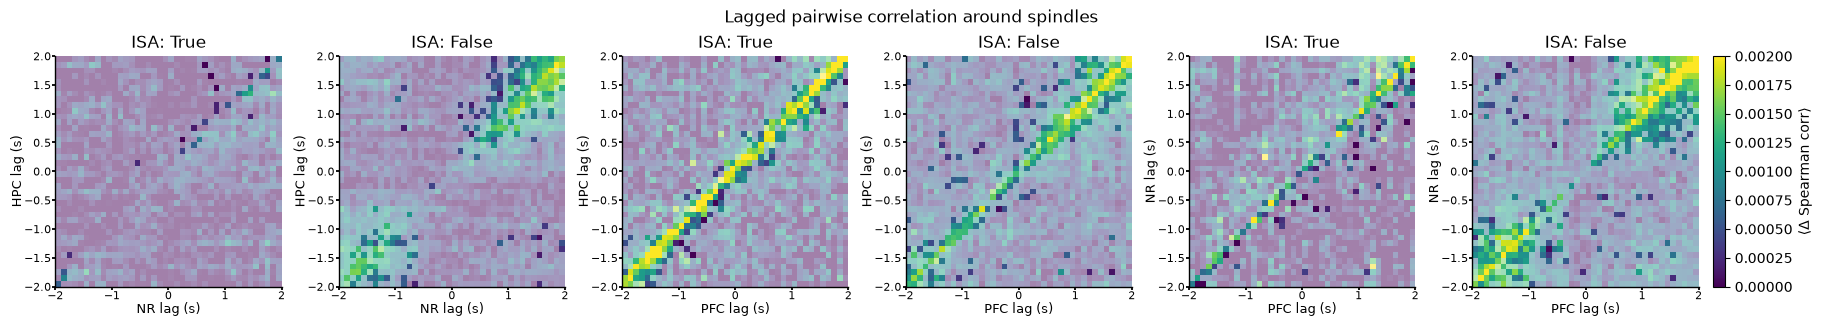

In [135]:
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation around {corr_spin_cat.event.values}',n=(1,6),size=(46,8))
vmin = 0. # 0.026 # for absolute values (not difference)
vmax = 0.002 # 0.032 # for absolute values (not difference)
label = [None,None,None,None,None,r'$\langle$Δ Spearman corr$\rangle$']
for i, r in enumerate(corr_spin_cat.reg.values[:3]):
    for a, isa in enumerate([True,False]):
        reg_data = corr_spin_cat.sel(reg=r,isa=isa)
        reg_data = reg_data.sel(shuffle=False) - reg_data.sel(shuffle=True)
        # significance
        w = sp.stats.wilcoxon(reg_data,axis=0,nan_policy='omit',alternative='greater').pvalue
        _, h = fma.analysis.holmBonferroni(w,return_reject=True)
        # plot result
        plotCMap(reg_data.mean(dim='rat',skipna=True).T,vmin=vmin,vmax=vmax,smooth=.2,alpha=np.where(h,1.0,0.5),bar=label[2*i+a],ax=ax[2*i+a],reg=r)
        ax[2*i+a].set(title=f'ISA: {isa}')
do_save and fma.plotting.saveFigure(fig,froot / 'spindleXCorr2',('png','svg'))

TEST: figure out which lag is which region

In [111]:
session = fma.data.readBatchFile(batch_file)[0][24]
print(f'session: {session}')
xdata = _laggedSpikeCrossCorr(session,event='ripples',bin=0.1,n_bins=5,step=1,target=[0,2],shift=5,pairs=[[0,1]])

session: /mnt/hubel-data-140/karadoc/Rat004_20240313/Rat004_20240313.xml
lagged (source): nr -0.2
  ref (target): hpc
  ref (target): hpc
lagged (source): nr -0.1
  ref (target): hpc
  ref (target): hpc
lagged (source): nr 0.0
  ref (target): hpc
  ref (target): hpc
lagged (source): nr 0.10000000000000003
  ref (target): hpc
  ref (target): hpc
lagged (source): nr 0.2
  ref (target): hpc
  ref (target): hpc


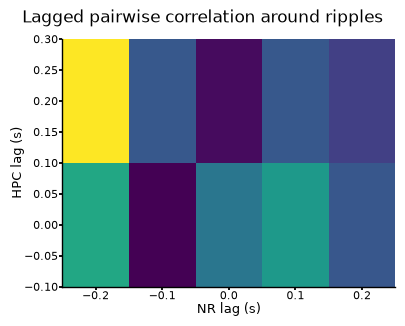

In [118]:
# interpretation: reg1 target, reg2 source
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation around {xdata.event.values}',n=(1,1),size=(10,8))
for i, r in enumerate(xdata.reg.values):
    reg_data = xdata.sel(reg=r,isa=True)
    plotCMap(reg_data.sel(shuffle=False).T,ax=ax[i],reg=r)